In [1]:
import numpyro.distributions as dist
import pandas as pd
import seaborn as sns
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.contrib.funsor import config_enumerate, infer_discrete

from numpyro.infer import (
    SVI,
    Trace_ELBO,
    TraceEnum_ELBO,
    TraceGraph_ELBO,
    TraceMeanField_ELBO,
    Predictive,
)
from numpyro.infer.autoguide import AutoNormal, init_to_median
from numpyro import handlers
from scvi.distributions import JaxNegativeBinomialMeanDisp

numpyro.set_platform("cpu")

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [2]:
!pip install --upgrade pip funsor numpyro

In [3]:
import jax.numpy as jnp
from jax import random


# cell count params
n_control = 1000
n_perturbed = 50
n_cells = n_control + n_perturbed

# gene params
n_genes = 1
gene_mean = jnp.array([2.0])
gene_disp = jnp.array([10.0])
# n_genes = 2
# gene_mean = jnp.array([10.0, 5.0])
# gene_disp = jnp.array([50.0, 10.0])

# guide params
n_guides = 2
efficiency = jnp.ones((n_guides, 1))
# efficiency = jnp.linspace(0.1, 0.9, num=n_guides).reshape(-1, 1)
log2_fc = jnp.array([-1.0])

guides_control = jnp.zeros((n_control, n_guides))
guides_perturbed = jnp.eye(n_guides).repeat(n_perturbed // n_guides, axis=0)
guides = jnp.vstack((guides_control, guides_perturbed))

print(guides.shape)
print(efficiency.shape)

(1050, 2)
(2, 1)


In [4]:
def create_plates(
    genes, n_cells=None, n_guides=None, subsample_size=None, n_genes=None, **kwargs
):
    if guides is not None:
        n_cells, n_guides = guides.shape
    if genes is not None:
        n_cells, n_genes = genes.shape
    if guides is not None and genes is not None:
        assert genes.shape[0] == guides.shape[0]

    cell_plate = numpyro.plate("cells", n_cells, dim=-2, subsample_size=subsample_size)
    genes_plate = numpyro.plate("genes", n_genes, dim=-1)

    guide_plate_T = numpyro.plate("guides_T", n_guides, dim=-2)
    guide_plate = numpyro.plate("guides", n_guides, dim=-1)
    plates = (cell_plate, guide_plate, guide_plate_T, genes_plate)
    return plates


# @config_enumerate
def perturbseq_model(
    genes,
    guides=None,
    log2_fc=None,
    gene_mean=None,
    gene_disp=None,
    efficiency=None,
    n_guides=5,
    n_cells=10,
    n_genes=1,
    efficiency_type="mixture",
    efficiency_alpha=3,
    efficiency_beta=1,
    eps=1e-6,
    subsample_size=None,
):
    # infer cell/guide numbers from data
    if guides is not None:
        n_cells, n_guides = guides.shape
    if genes is not None:
        n_cells, n_genes = genes.shape
    if guides is not None and genes is not None:
        assert genes.shape[0] == guides.shape[0]

    # create plates
    cell_plate, guide_plate, guide_plate_T, gene_plate = create_plates(
        genes,
        n_cells=n_cells,
        n_guides=n_guides,
        n_genes=n_genes,
        subsample_size=subsample_size,
    )

    # constants and gene-level params
    with gene_plate:
        baseline_mean = numpyro.sample("mean", dist.LogNormal(0.0, 4.0), obs=gene_mean)
        dispersion = numpyro.sample(
            "dispersion", dist.LogNormal(2.0, 2.0), obs=gene_disp
        )

    # sample guide efficiency & effect sizes
    # efficiency_alpha = jnp.array(5.0)
    # efficiency_beta = jnp.array(2.0)
    with gene_plate:
        with guide_plate_T:
            guide_efficiency = numpyro.sample(
                "efficiency",
                dist.Beta(efficiency_alpha, efficiency_beta),
                obs=efficiency,
            )
    prior_inclusion_prob = 0.05
    inclusion_probs = jnp.stack(
        [1 - prior_inclusion_prob, prior_inclusion_prob], axis=-1
    )

    with gene_plate:
        # log2_fc = numpyro.sample("log2_fold_change", dist.Cauchy(0.0, 0.1), obs=log2_fc)
        # log2_fc = numpyro.sample("log2_fold_change", dist.Cauchy(0.0, 0.1), obs=log2_fc)

        non_effect_scale = 0.1
        effect_scale = 3.0
        effect_scales = jnp.stack([non_effect_scale, effect_scale], axis=-1)
        # inclusion = numpyro.sample("include", dist.Categorical(inclusion_probs))
        # log2_fc = numpyro.sample(
        #     "log2_fold_change", dist.Normal(0.0, effect_scales[inclusion]), obs=log2_fc
        # )
        # inclusion = numpyro.sample(
        #     "include",
        #     ,
        #     infer={"enumerate": "parallel"},
        # )
        # print(inclusion.shape)

        log2_fc = numpyro.sample(
            "log2_fold_change",
            dist.MixtureSameFamily(
                dist.Categorical(inclusion_probs), dist.Normal(0.0, effect_scales)
            ),
            obs=log2_fc,
        )

    # sample gene values for each cell
    with cell_plate:
        if guides is not None:
            guides = numpyro.subsample(guides, event_dim=0)
        if genes is not None:
            genes = numpyro.subsample(genes, event_dim=0)

        with guide_plate:
            guide_prob = jnp.array(1 / n_guides)
            guide_obs = numpyro.sample(
                "guide_obs", dist.Binomial(1, probs=guide_prob), obs=guides
            )

        if efficiency_type == "mixture":
            # guide_inactivity = (1 - guide_obs * guide_efficiency).prod(
            #     axis=-1, keepdims=True
            # )
            guide_inactivity_logit = jnp.log(
                1
                - jnp.tile(jnp.expand_dims(guide_obs, axis=-1), (1, 1, n_genes))
                * guide_efficiency
            ).sum(axis=-2)

            # guide_activity_logit = jnp.log(1 - jnp.exp(guide_inactivity_logit))
            guide_activity_logit = jnp.log1p(-jnp.exp(guide_inactivity_logit) + eps)

            # mix_probs = jnp.stack([guide_inactivity, 1 - guide_inactivity], axis=-1)
            mix_logits = jnp.stack(
                [guide_inactivity_logit, guide_activity_logit], axis=-1
            )
            mix_dist = dist.Categorical(logits=mix_logits)
            guide_effect = log2_fc * jnp.log(2)
            base_logit = jnp.log(baseline_mean) - jnp.log(dispersion)
            logits = jnp.stack([base_logit, guide_effect + base_logit], axis=-1)
            component_dist = dist.NegativeBinomialLogits(
                logits=logits, total_count=dispersion
            )
            obs_dist = dist.MixtureSameFamily(mix_dist, component_dist)

        elif efficiency_type == "scale":
            guide_effect = guide_obs @ (log2_fc * guide_efficiency) * jnp.log(2)
            logits = guide_effect + jnp.log(baseline_mean) - jnp.log(dispersion)
            obs_dist = dist.NegativeBinomialLogits(
                logits=logits, total_count=dispersion
            )
            # logits = guide_effect + jnp.log(baseline_mean)
            # obs_dist = JaxNegativeBinomialMeanDisp(
            #     mean=jnp.exp(logits), inverse_dispersion=dispersion
            # )
        with gene_plate:
            gene_obs = numpyro.sample("gene_obs", obs_dist, obs=genes)

    return gene_obs

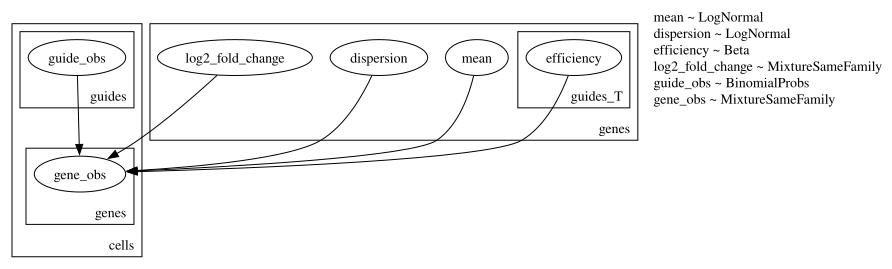

In [5]:
numpyro.render_model(
    perturbseq_model,
    model_args=(None,),
    render_distributions=True,
    render_params=True,
)

In [6]:

rng_key = random.PRNGKey(0)

# Define your model parameters
model_params = {
    'guides': guides,
    'log2_fc': log2_fc,
    'efficiency': efficiency,
    'gene_mean': gene_mean,
    'gene_disp': gene_disp,
}

# Create a predictive model
predictive = Predictive(perturbseq_model, num_samples=1)

# Sample from the model
samples = predictive(rng_key, None, **model_params)

# The samples object will be a dictionary where each key is a variable name in your model
# and the value is an array of samples for that variable.
# For example, to get the shape of the 'gene_obs' samples:
gene_obs = samples['gene_obs'][0, ...]
gene_obs.shape

(1050, 1)

In [7]:
for k, v in samples.items():
    v = v[0,...]
    print(k, v.shape, v)

dispersion (1,) [10.]
efficiency (2, 1) [[1.]
 [1.]]
gene_obs (1050, 1) [[1]
 [1]
 [3]
 ...
 [1]
 [1]
 [2]]
guide_obs (1050, 2) [[0. 0.]
 [0. 0.]
 [0. 0.]
 ...
 [0. 1.]
 [0. 1.]
 [0. 1.]]
log2_fold_change (1,) [-1.]
mean (1,) [2.]


In [8]:
data_df = pd.DataFrame(gene_obs).assign(
    guide=guides.argmax(axis=1) + (guides.sum(axis=1) > 0)
)
data_df
data_df.value_counts("guide")

guide
0    1000
1      25
2      25
Name: count, dtype: int64

In [9]:
gene_obs.shape

(1050, 1)

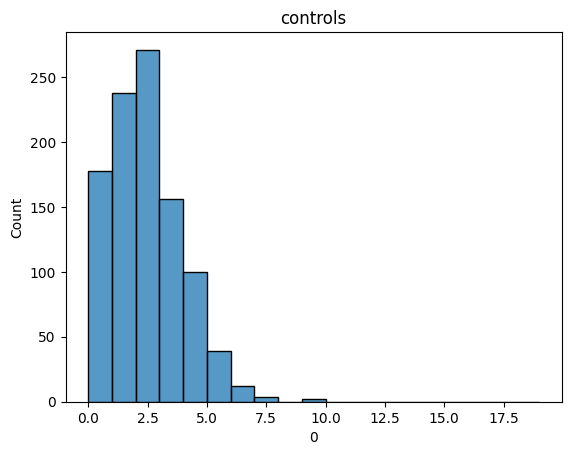

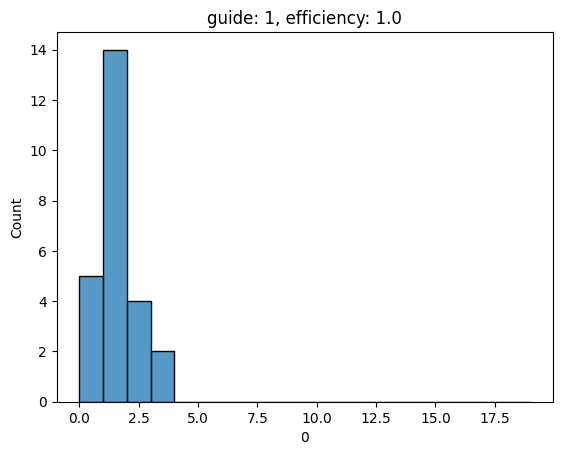

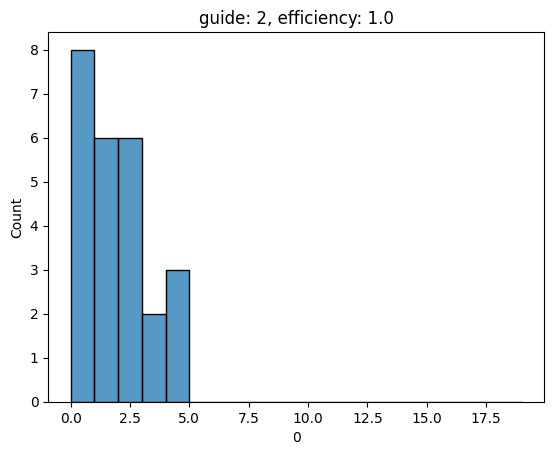

In [10]:
max_count = 20
counts_col = 0
bins = np.arange(max_count).astype(int)
plt.title("controls")
sns.histplot(data_df.query("guide==0"), x=counts_col, bins=bins)
plt.show()
for guide in range(n_guides):
    plt.title(f"guide: {guide+1}, efficiency: {efficiency[guide,0]:.1f}")
    sns.histplot(data_df.query(f"guide=={guide+1}"), x=counts_col, bins=bins)
    plt.show()

In [11]:
def train(args, kwargs, model, guide, lr=0.01, n_steps=1000):
    # adam_params = {"lr": lr}
    adam = numpyro.optim.Adam(step_size=lr)
    svi = SVI(
        model,
        guide,
        adam,
        loss=TraceGraph_ELBO(),
    )
    svi_result = svi.run(random.PRNGKey(0), n_steps, args, **kwargs)
    return svi_result

In [12]:
perturbseq_guide = AutoNormal(
    handlers.block(
        handlers.seed(perturbseq_model, random.PRNGKey(0)), hide=["include"]
    ),
    # init_loc_fn=init_to_median,
    create_plates=create_plates,
)

100%|██████████| 4000/4000 [00:02<00:00, 1823.47it/s, init loss: 3450.5884, avg. loss [3801-4000]: 3286.1950]


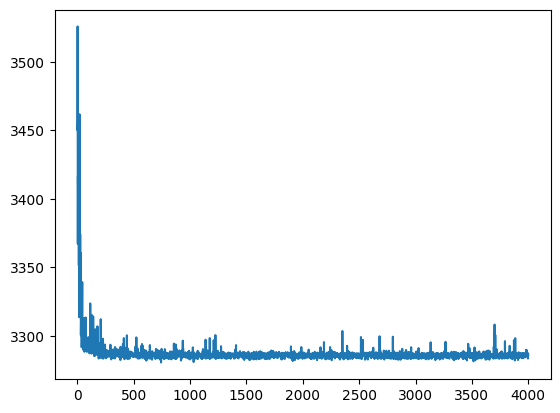

In [13]:
svi_result = train(
    gene_obs,
    dict(guides=guides, subsample_size=None),
    perturbseq_model,
    perturbseq_guide,
    n_steps=4000,
    lr=0.01,
)
# losses = train(gene_obs, dict(guides=guides, log2_fc=log2_fc, latent_activity=True), perturbseq_model, perturbseq_guide)
plt.plot(svi_result.losses)

In [14]:
unconstrained_locs = dict()
for k, v in svi_result.params.items():
    print(k, v.shape, v)
    param, param_type = k.split("_auto_")
    if param_type == "loc":
        unconstrained_locs[param] = v
print(unconstrained_locs)

dispersion_auto_loc (1,) [2.6078498]
dispersion_auto_scale (1,) [0.3723039]
efficiency_auto_loc (2, 1) [[1.9807844]
 [1.4154017]]
efficiency_auto_scale (2, 1) [[1.2442379]
 [1.1457894]]
log2_fold_change_auto_loc (1,) [-0.5224459]
log2_fold_change_auto_scale (1,) [0.30138704]
mean_auto_loc (1,) [0.6757598]
mean_auto_scale (1,) [0.0239952]
{'dispersion': Array([2.6078498], dtype=float32), 'efficiency': Array([[1.9807844],
       [1.4154017]], dtype=float32), 'log2_fold_change': Array([-0.5224459], dtype=float32), 'mean': Array([0.6757598], dtype=float32)}


In [15]:
# perturbseq_guide.median()
# svi.get_p
predictive_svi = Predictive(
    perturbseq_guide,
    params=svi_result.params,
    num_samples=10000,
)

svi_posterior_samples = predictive_svi(rng_key, None, guides=guides, n_genes=n_genes)

svi_posterior_samples.keys()

dict_keys(['dispersion', 'efficiency', 'log2_fold_change', 'mean'])

In [16]:
# locs = {k: perturbseq_guide._get_loc_and_scale(k)[0].detach() for k in perturbseq_guide..()}
# locs
params = svi_result.params
params

{'dispersion_auto_loc': Array([2.6078498], dtype=float32),
 'dispersion_auto_scale': Array([0.3723039], dtype=float32),
 'efficiency_auto_loc': Array([[1.9807844],
        [1.4154017]], dtype=float32),
 'efficiency_auto_scale': Array([[1.2442379],
        [1.1457894]], dtype=float32),
 'log2_fold_change_auto_loc': Array([-0.5224459], dtype=float32),
 'log2_fold_change_auto_scale': Array([0.30138704], dtype=float32),
 'mean_auto_loc': Array([0.6757598], dtype=float32),
 'mean_auto_scale': Array([0.0239952], dtype=float32)}

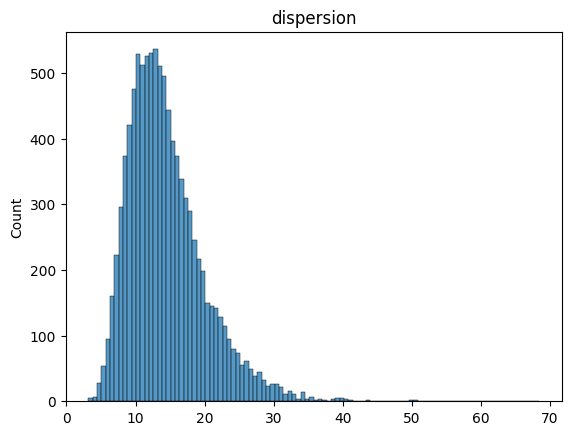

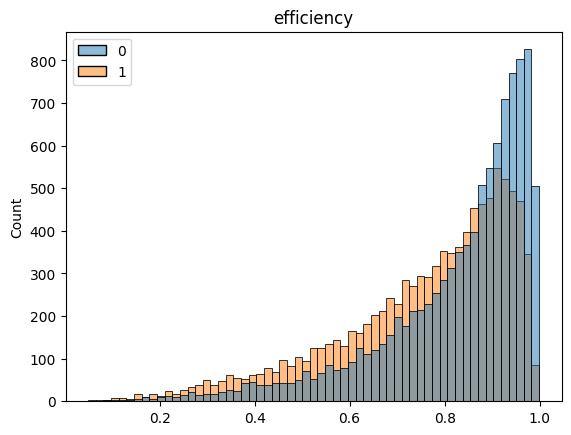

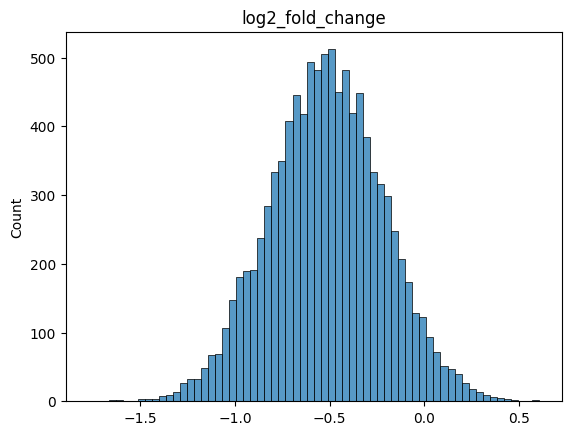

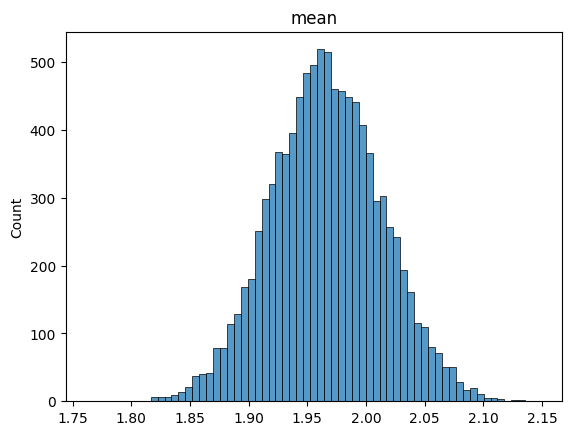

In [17]:
for k, v in svi_posterior_samples.items():
    v = v[..., 0]
    plt.title(k)
    sns.histplot(v)
    plt.show()

In [18]:
# break

## MCMC

In [19]:
from numpyro.infer import MCMC, NUTS, HMCECS, DiscreteHMCGibbs

n_chains = 1

kernel = NUTS(
    perturbseq_model,
    # dense_mass=[("mean", "dispersion", "log2_fold_change")],
)
# kernel = DiscreteHMCGibbs(kernel, random_walk=True)


mcmc = MCMC(kernel, num_samples=10000, num_warmup=1000, num_chains=n_chains)

In [20]:
mcmc.run(
    random.PRNGKey(0), gene_obs, **dict(guides=guides), init_params=unconstrained_locs
)

sample: 100%|██████████| 11000/11000 [00:16<00:00, 666.30it/s, 7 steps of size 3.12e-01. acc. prob=0.88] 


In [21]:
samples = mcmc.get_samples()
samples

{'dispersion': Array([[34.499557],
        [39.78076 ],
        [ 8.304675],
        ...,
        [ 8.312015],
        [15.627535],
        [ 9.816995]], dtype=float32),
 'efficiency': Array([[[0.9654858 ],
         [0.70413536]],
 
        [[0.9974377 ],
         [0.9065877 ]],
 
        [[0.56561035],
         [0.40128678]],
 
        ...,
 
        [[0.8640802 ],
         [0.40805838]],
 
        [[0.9354346 ],
         [0.85711074]],
 
        [[0.8238661 ],
         [0.26780745]]], dtype=float32),
 'log2_fold_change': Array([[-0.86718804],
        [-0.5871849 ],
        [-1.161657  ],
        ...,
        [-0.1031312 ],
        [-0.1858523 ],
        [-0.25477198]], dtype=float32),
 'mean': Array([[2.00062  ],
        [1.8889275],
        [2.0032573],
        ...,
        [2.0217576],
        [1.9594668],
        [1.99895  ]], dtype=float32)}

In [22]:
for k, v in samples.items():
    v = v[..., 0]
    samples[k] = v
    print(f"{k}: {tuple(v.shape)}")

dispersion: (10000,)
efficiency: (10000, 2)
log2_fold_change: (10000,)
mean: (10000,)


In [23]:
samples["mean"]

Array([2.00062  , 1.8889275, 2.0032573, ..., 2.0217576, 1.9594668,
       1.99895  ], dtype=float32)

(array([1.000e+00, 2.300e+01, 3.760e+02, 1.566e+03, 3.151e+03, 2.989e+03,
        1.480e+03, 3.640e+02, 4.400e+01, 6.000e+00]),
 array([1.73140907, 1.773615  , 1.81582105, 1.85802698, 1.90023303,
        1.94243896, 1.98464489, 2.02685094, 2.06905699, 2.1112628 ,
        2.15346885]),
 <BarContainer object of 10 artists>)

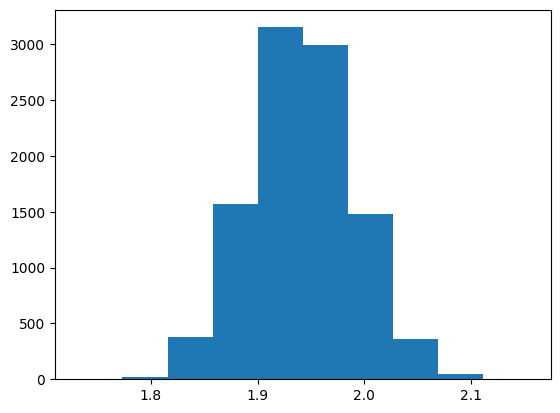

In [24]:
plt.hist(samples["mean"])


Array([34.499557, 39.78076 ,  8.304675, ...,  8.312015, 15.627535,
        9.816995], dtype=float32)

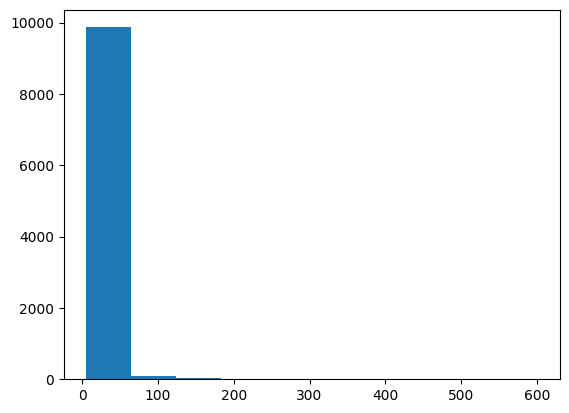

In [25]:
plt.hist(samples["dispersion"])
samples["dispersion"]

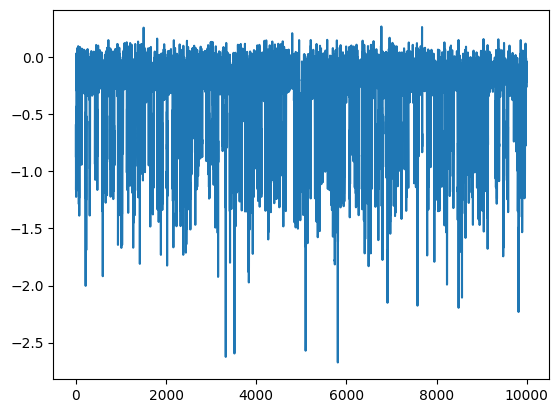

In [26]:
plt.plot(samples["log2_fold_change"])

<Axes: ylabel='Count'>

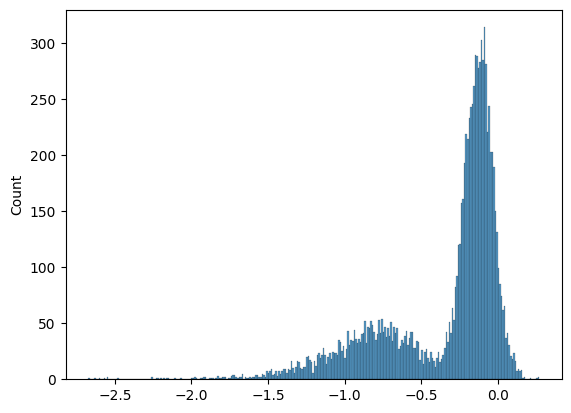

In [27]:
sns.histplot(samples["log2_fold_change"], binwidth=0.01)

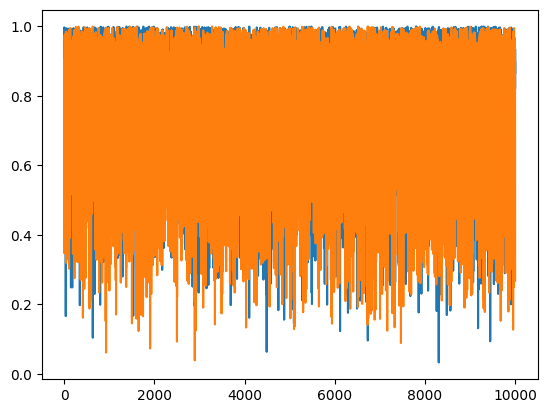

In [28]:
plt.plot(samples["efficiency"])

<Axes: ylabel='Count'>

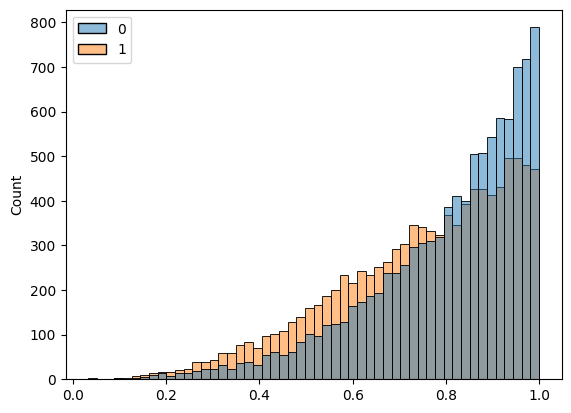

In [29]:
sns.histplot(samples["efficiency"])

<Axes: ylabel='Count'>

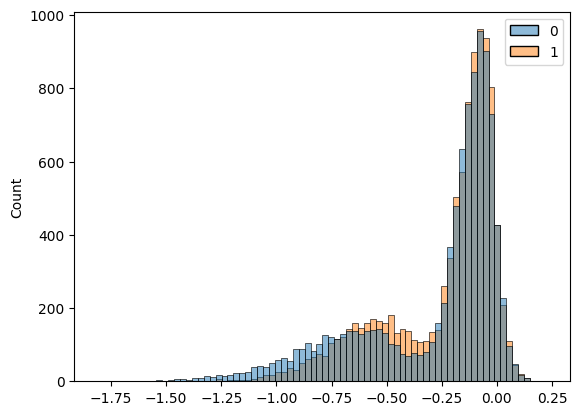

In [30]:
sns.histplot(samples["efficiency"]*samples["log2_fold_change"].reshape(-1,1))

<Axes: ylabel='Count'>

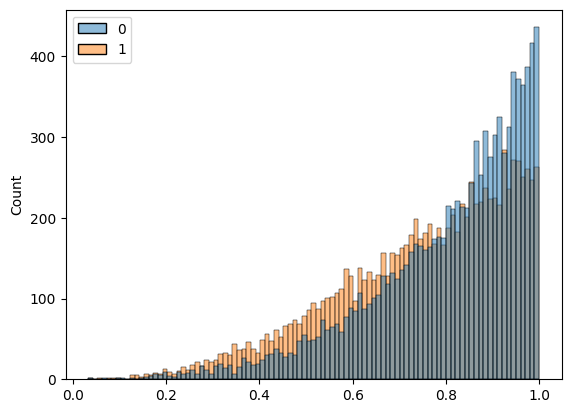

In [31]:
sns.histplot(pd.DataFrame(samples["efficiency"]), binwidth=0.01)

## use HMCECS to run MCMC with subsampling
(scrapped)

In [32]:
# predictive = Predictive(perturbseq_model, samples)(
#     random.PRNGKey(0), None, guides=guides
# )
# for k, v in predictive.items():
#     print(f"{k}: {tuple(v.shape)}")
break

SyntaxError: 'break' outside loop (2184186719.py, line 6)

In [ ]:
from numpyro.infer import MCMC, NUTS, HMCECS

hmces_kernel = HMCECS(NUTS(perturbseq_model), num_blocks=5)
# subsample_size = 
mcmc = MCMC(hmces_kernel, num_samples=10000, num_warmup=1000, num_chains=2) 


/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_21699/81139678.py:5: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(hmces_kernel, num_samples=10000, num_warmup=1000, num_chains=2)


In [ ]:
mcmc.run(random.PRNGKey(0), gene_obs, **dict(guides=guides, subsample_size=1000))

sample: 100%|██████████| 11000/11000 [00:56<00:00, 193.85it/s, 13 steps of size 3.58e-01. acc. prob=0.84]


In [ ]:
samples = mcmc.get_samples()
for k, v in samples.items():
    print(f"{k}: {tuple(v.shape)}")


dispersion: (20000,)
efficiency: (20000, 5)
log2_fold_change: (20000,)
mean: (20000,)


(array([1.480e+02, 1.737e+03, 5.035e+03, 6.208e+03, 4.088e+03, 1.886e+03,
        6.960e+02, 1.650e+02, 3.400e+01, 3.000e+00]),
 array([0.02306658, 0.02948077, 0.03589497, 0.04230917, 0.04872336,
        0.05513756, 0.06155175, 0.06796595, 0.07438014, 0.08079433,
        0.08720853]),
 <BarContainer object of 10 artists>)

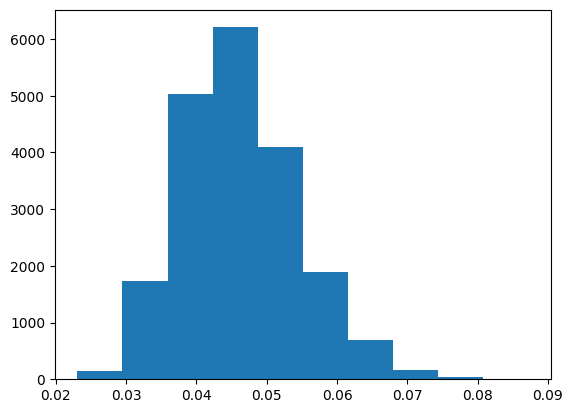

In [ ]:
plt.hist(samples["mean"])


(array([1.9737e+04, 1.3900e+02, 4.8000e+01, 3.1000e+01, 3.5000e+01,
        6.0000e+00, 3.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([3.17884892e-01, 1.20765137e+03, 2.41498486e+03, 3.62231812e+03,
        4.82965186e+03, 6.03698535e+03, 7.24431836e+03, 8.45165234e+03,
        9.65898535e+03, 1.08663193e+04, 1.20736523e+04]),
 <BarContainer object of 10 artists>)

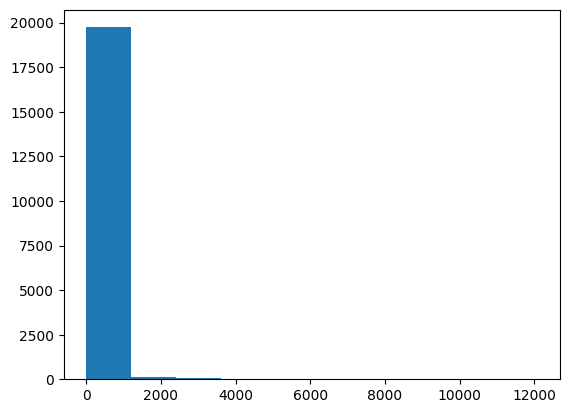

In [ ]:
plt.hist(samples["dispersion"])

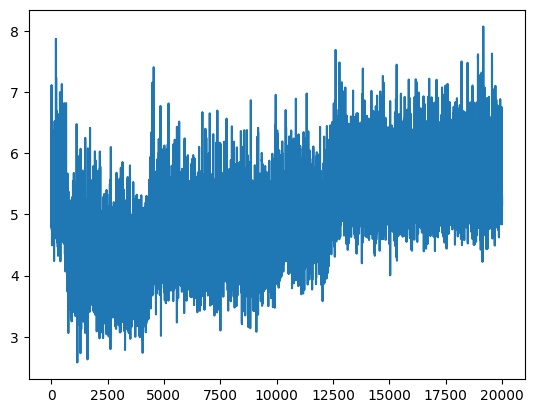

In [ ]:
plt.plot(samples["log2_fold_change"])

<Axes: ylabel='Count'>

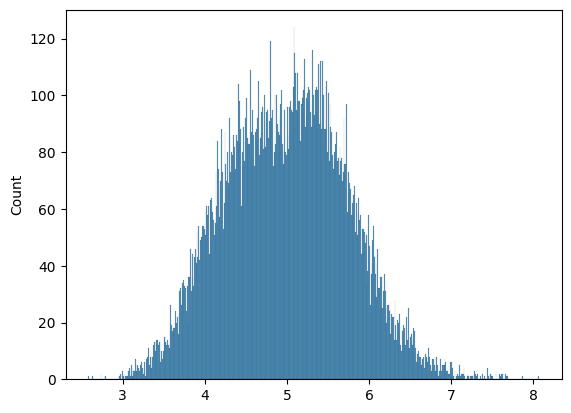

In [ ]:
sns.histplot(samples["log2_fold_change"], binwidth=0.01)

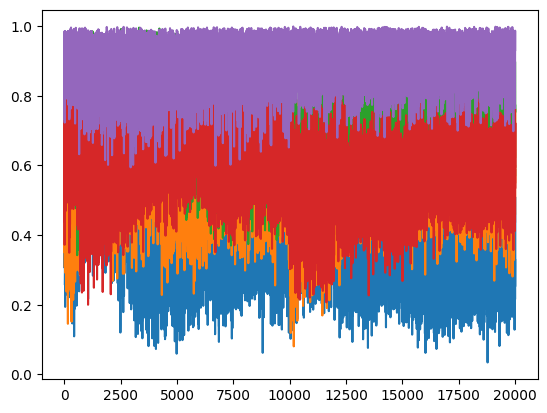

In [ ]:
plt.plot(samples["efficiency"])

<Axes: ylabel='Count'>

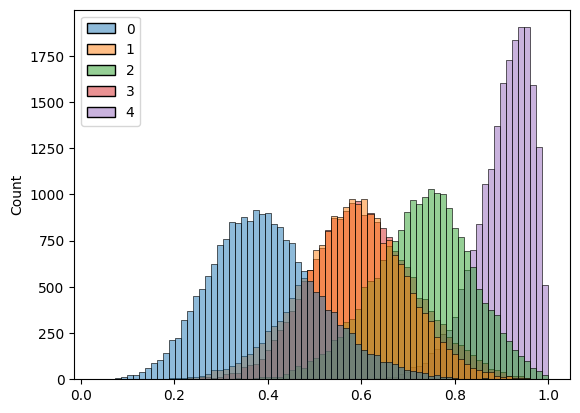

In [ ]:
sns.histplot(samples["efficiency"])

<Axes: ylabel='Count'>

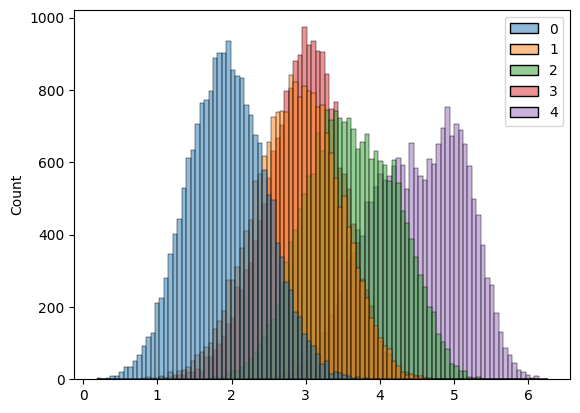

In [ ]:
sns.histplot(samples["efficiency"]*samples["log2_fold_change"].reshape(-1,1))